In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
df=pd.read_csv("Titanic-Dataset.csv")
df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
null_counts = df.isnull().sum()
null_counts

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [5]:
df.drop('Cabin', axis=1, inplace=True)

In [6]:
df=df.fillna({"Age":df['Age'].median()}, inplace=True)

In [7]:
print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       2
dtype: int64


In [8]:
df=df.fillna({"Age":df["Embarked"].mode()[0]},inplace=True)

In [9]:
print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       2
dtype: int64


In [10]:
print(df['Embarked'].unique())


<StringArray>
['S', 'C', 'Q', nan]
Length: 4, dtype: str


In [11]:
# Map 'male' to 0 and 'female' to 1
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

In [12]:
# Apply one-hot encoding to 'Embarked'
df = pd.get_dummies(df, columns=['Embarked'], prefix='Embarked', drop_first=True)

In [13]:
df = pd.get_dummies(df, columns=['Pclass'], prefix='Pclass', drop_first=True)

In [14]:
from sklearn.preprocessing import MinMaxScaler

# Initialize the scaler
min_max_scaler = MinMaxScaler()

# Fit and transform 'Age'
# Note: Use double brackets [['Age']] to maintain 2D structure
df[["Age"]] = min_max_scaler.fit_transform(df[["Age"]])

C:\Users\mahad\AppData\Local\Temp\ipykernel_14508\1071554970.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot([df[col].dropna() for col in numerical_cols],


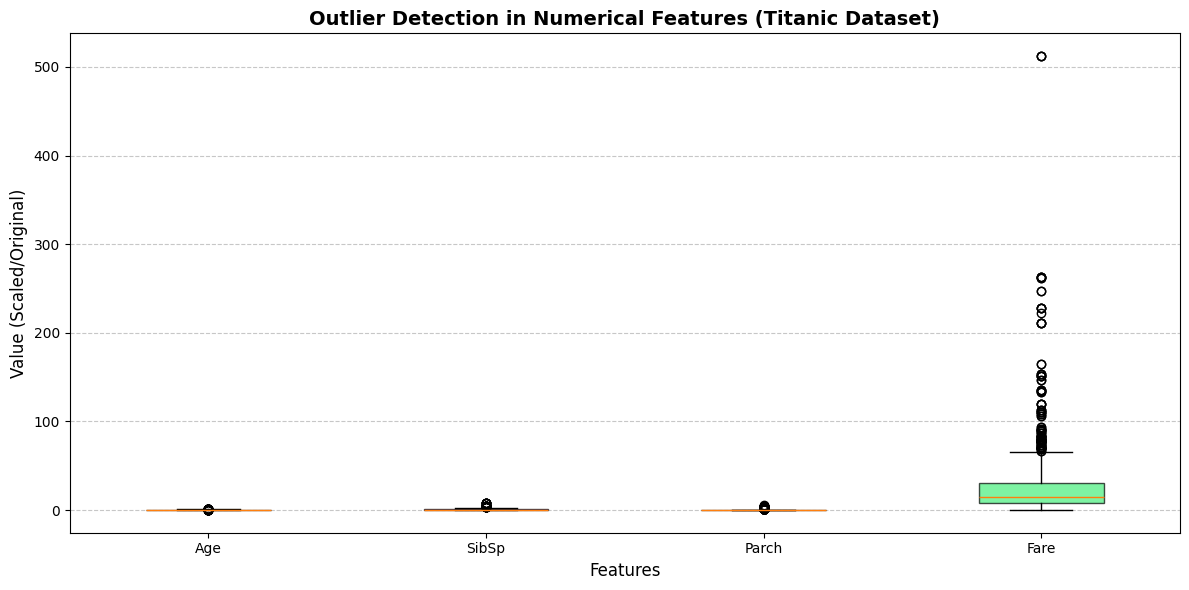

In [15]:

# Define the numerical columns to inspect
numerical_cols = ['Age', 'SibSp', 'Parch', 'Fare']

# Create a figure and a set of subplots
# figsize=(12, 6) provides a wide aspect ratio for clarity
fig, ax = plt.subplots(figsize=(12, 6))

# Generate boxplots for the specified columns
# patch_artist=True allows for color customization of the boxes
box = ax.boxplot([df[col].dropna() for col in numerical_cols], 
                 labels=numerical_cols, 
                 patch_artist=True,
                 notch=False,
                 vert=True)

# Customize colors for better visual distinction
colors = ['#8D1651', '#7D48EE', '#efc6ec', '#48EE7D']
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# Add titles and labels
ax.set_title('Outlier Detection in Numerical Features (Titanic Dataset)', fontsize=14, fontweight='bold')
ax.set_ylabel('Value (Scaled/Original)', fontsize=12)
ax.set_xlabel('Features', fontsize=12)

# Add grid for easier reading
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

# Adjust layout to prevent label clipping
plt.tight_layout()

# Display the plot
plt.show()

In [16]:
df.head()

,PassengerId,Survived,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked_Q,Embarked_S,Pclass_2,Pclass_3
0,1,0,"Braund, Mr. Owen Harris",0,0.271174,1,0,A/5 21171,7.2500,False,True,False,True
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,0.472229,1,0,PC 17599,71.2833,False,False,False,False
2,3,1,"Heikkinen, Miss. Laina",1,0.321438,0,0,STON/O2. 3101282,7.9250,False,True,False,True
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,0.434531,1,0,113803,53.1000,False,True,False,False
4,5,0,"Allen, Mr. William Henry",0,0.434531,0,0,373450,8.0500,False,True,False,True


In [17]:
def remove_outliers_iqr(df, column):
    """
    Removes outliers from a specified column using the Interquartile Range (IQR) method.
    
    Parameters:
    df (pd.DataFrame): The input DataFrame.
    column (str): The name of the column to process.
    
    Returns:
    pd.DataFrame: The DataFrame with outliers removed for the specified column.
    """
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Filter the DataFrame
    initial_count = len(df)
    df_filtered = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    final_count = len(df_filtered)
    
    print(f"Column '{column}': Removed {initial_count - final_count} outliers. "
          f"Bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
    
    return df_filtered

# Apply outlier removal to key numerical features
# Note: It is often best to remove outliers from 'Fare' and 'Age' specifically
df_cleaned = remove_outliers_iqr(df, 'Fare')
df_cleaned = remove_outliers_iqr(df_cleaned, 'Age')

# Verify the new shape
print(f"Original Dataset Shape: {df.shape}")
print(f"Cleaned Dataset Shape: {df_cleaned.shape}")

Column 'Fare': Removed 116 outliers. Bounds: [-26.72, 65.63]
Column 'Age': Removed 67 outliers. Bounds: [0.04, 0.65]
Original Dataset Shape: (891, 13)
Cleaned Dataset Shape: (708, 13)


In [19]:
df.to_csv("Titanic-Dataset-Cleaned.csv", index=False)